First Cell it applying Filter of NYSE and Value of Stocks requested

In [503]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetClass, AssetStatus

from alpaca.data import StockHistoricalDataClient, StockBarsRequest
from alpaca.data.timeframe import TimeFrame

API_KEY = "PK4TWZVLG6IO4EFHF75EOAX6Y5"
API_SECRET = "49eCLqf7RbEibmmx5gJPm1LgukT88xA2fgfTJRjFt1Wo"

trading_client = TradingClient(API_KEY, API_SECRET)
data_client = StockHistoricalDataClient(API_KEY, API_SECRET)

# 1) Get all active US equities on NYSE
assets_req = GetAssetsRequest(
    status=AssetStatus.ACTIVE,
    asset_class=AssetClass.US_EQUITY
)

all_assets = trading_client.get_all_assets(assets_req)

nyse_symbols = [
    a.symbol
    for a in all_assets
    if a.exchange == "NYSE" and a.tradable
]

print(f"NYSE tradable count: {len(nyse_symbols)}")

# 2) Get a recent close price and filter to < $50
end = datetime.today()
start = end - timedelta(days=50)   # buffer in case of holidays

def get_latest_close(symbols):
    """Return last available close for each symbol in `symbols`."""
    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
    )
    bars = data_client.get_stock_bars(req).df
    # bars index: (symbol, timestamp)
    # take last bar per symbol
    last = bars.groupby(level=0).tail(1)['close']
    return last

# Chunk to avoid huge single request
chunk_size = 200
closes_list = []

for i in range(0, len(nyse_symbols), chunk_size):
    chunk = nyse_symbols[i:i+chunk_size]
    try:
        last = get_latest_close(chunk)
        closes_list.append(last)
    except Exception as e:
        print("Error on chunk", i, e)

closes = pd.concat(closes_list)
closes = closes.dropna()

universe = closes[closes < 50].index.tolist()
print(f"Universe size (NYSE, price < $50): {len(universe)}")


NYSE tradable count: 2890
Universe size (NYSE, price < $50): 2121


In [504]:
from datetime import datetime, timedelta

from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetClass, AssetStatus

from alpaca.data import StockHistoricalDataClient, StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# === CONFIG ===
API_KEY = "PK4TWZVLG6IO4EFHF75EOAX6Y5"
API_SECRET = "49eCLqf7RbEibmmx5gJPm1LgukT88xA2fgfTJRjFt1Wo"

trading_client = TradingClient(API_KEY, API_SECRET)
data_client = StockHistoricalDataClient(API_KEY, API_SECRET)

# 1) Get all active US equities on NYSE
assets_req = GetAssetsRequest(
    status=AssetStatus.ACTIVE,
    asset_class=AssetClass.US_EQUITY
)

all_assets = trading_client.get_all_assets(assets_req)

nyse_symbols = [
    a.symbol
    for a in all_assets
    if a.exchange == "NYSE" and a.tradable
]

print(f"NYSE tradable count: {len(nyse_symbols)}")

# 2) Get a recent close price and filter to < $50
end_latest = datetime.today()
start_latest = end_latest - timedelta(days=10)   # buffer in case of holidays

def get_latest_close(symbols):
    """Return last available close for each symbol in `symbols` (index = symbol)."""
    if not symbols:
        return pd.Series(dtype=float)

    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start_latest,
        end=end_latest,
    )
    bars = data_client.get_stock_bars(req).df

    if bars.empty:
        return pd.Series(dtype=float)

    # bars index: (symbol, timestamp)
    # -> take last close per symbol, index = symbol (no MultiIndex)
    last = bars['close'].groupby(level=0).last()
    return last

# Chunk to avoid huge single request
chunk_size = 200
closes_list = []

for i in range(0, len(nyse_symbols), chunk_size):
    chunk = nyse_symbols[i:i + chunk_size]
    try:
        last = get_latest_close(chunk)
        closes_list.append(last)
        print(f"Got latest closes for chunk {i // chunk_size + 1}")
    except Exception as e:
        print("Error on chunk", i, e)

closes = pd.concat(closes_list)
closes = closes.dropna()

# Universe: NYSE stocks with last close < $50
universe = closes[closes < 50].index.astype(str).tolist()
print(f"Universe size (NYSE, price < $50): {len(universe)}")
print("First few symbols in universe:", universe[:10])

# 3) Get 4 years of daily history for this universe
hist_end = datetime.today()
hist_start = hist_end - timedelta(days=365 * 4)

hist_start_str = hist_start.strftime("%Y-%m-%d")
hist_end_str   = hist_end.strftime("%Y-%m-%d")

def get_price_history(symbols, start, end, chunk_size=200):
    """
    Fetch daily OHLCV from Alpaca and return:
      - prices: wide DataFrame of daily CLOSE prices
      - volumes: wide DataFrame of daily VOLUME
    index: timestamp (date)
    columns: ticker symbols
    """
    all_price_chunks = []
    all_volume_chunks = []

    for i in range(0, len(symbols), chunk_size):
        chunk = symbols[i:i + chunk_size]
        print(f"Requesting history for chunk {i}–{i+len(chunk)} ({len(chunk)} symbols)")

        try:
            req = StockBarsRequest(
                symbol_or_symbols=chunk,
                timeframe=TimeFrame.Day,
                start=start,
                end=end
            )
            bars = data_client.get_stock_bars(req).df
            # bars is usually MultiIndex with levels ['symbol', 'timestamp']
            if bars.empty:
                print(f"No bars returned for chunk {i}")
                continue

            if isinstance(bars.index, pd.MultiIndex):
                idx_names = list(bars.index.names)
                # try to locate the 'symbol' level
                if "symbol" in idx_names:
                    sym_level = idx_names.index("symbol")
                else:
                    # fallback: assume level 0 is symbol
                    sym_level = 0

                # unstack so that columns = symbols, index = timestamp
                closes = bars["close"].unstack(level=sym_level)
                volumes = bars["volume"].unstack(level=sym_level)

            else:
                # Single index: reset and pivot
                bars = bars.reset_index()
                if "symbol" not in bars.columns:
                    raise ValueError("Expected 'symbol' column in bars DataFrame.")
                if "timestamp" not in bars.columns:
                    raise ValueError("Expected 'timestamp' column in bars DataFrame.")

                closes = bars.pivot(index="timestamp", columns="symbol", values="close")
                volumes = bars.pivot(index="timestamp", columns="symbol", values="volume")

            all_price_chunks.append(closes)
            all_volume_chunks.append(volumes)

        except Exception as e:
            print(f"Error on history chunk {i}: {e}")

    if not all_price_chunks:
        raise ValueError("No price data returned for any symbols.")

    # IMPORTANT: stitch chunks horizontally (axis=1), aligning on timestamps
    prices = pd.concat(all_price_chunks, axis=1).sort_index()
    volumes = pd.concat(all_volume_chunks, axis=1).sort_index()

    # Remove duplicate columns if any
    prices = prices.loc[:, ~prices.columns.duplicated()]
    volumes = volumes.loc[:, ~volumes.columns.duplicated()]

    print("Finished downloading OHLCV history.")
    print("Sample of prices (first 5 dates, 5 symbols):")
    print(prices.iloc[:5, :5])

    return prices, volumes

prices, volumes = get_price_history(universe, hist_start_str, hist_end_str, chunk_size=200)
print("Raw prices shape:", prices.shape)
print(prices.isna().mean().describe())

NYSE tradable count: 2890
Got latest closes for chunk 1
Got latest closes for chunk 2
Got latest closes for chunk 3
Got latest closes for chunk 4
Got latest closes for chunk 5
Got latest closes for chunk 6
Got latest closes for chunk 7
Got latest closes for chunk 8
Got latest closes for chunk 9
Got latest closes for chunk 10
Got latest closes for chunk 11
Got latest closes for chunk 12
Got latest closes for chunk 13
Got latest closes for chunk 14
Got latest closes for chunk 15
Universe size (NYSE, price < $50): 2121
First few symbols in universe: ['AA', 'AAM.U', 'AAM.WS', 'AAMI', 'AAT', 'AAUC', 'ABEV', 'ABM', 'ABR', 'ALUB.U']
Requesting history for chunk 0–200 (200 symbols)
Requesting history for chunk 200–400 (200 symbols)
Requesting history for chunk 400–600 (200 symbols)
Requesting history for chunk 600–800 (200 symbols)
Requesting history for chunk 800–1000 (200 symbols)
Requesting history for chunk 1000–1200 (200 symbols)
Requesting history for chunk 1200–1400 (200 symbols)
Reques

In [505]:
# ========= 0) Quick sanity check on raw prices =========
print("Raw prices shape:", prices.shape)
print("NaN fraction per column (summary):")
print(prices.isna().mean().describe())

# ========= 1) Compute returns =========
# (Don't drop rows yet, we just want counts per symbol)
rets = prices.pct_change(fill_method=None)

# ========= 2) Relaxed data-quality filter =========
# Instead of "80% of all days", require at least min_days of data.
# e.g. min_days = 252 ≈ 1 trading year
min_days = 252

valid_cols = [c for c in rets.columns if rets[c].count() >= min_days]

rets = rets[valid_cols]
prices_clean  = prices[valid_cols]
volumes_clean = volumes[valid_cols]

print(f"Symbols after min_days>={min_days} filter: {len(valid_cols)}")

# If this is still tiny, you can lower min_days to e.g. 126 or 100.

# ========= 3) ADV filter using TRAIN PERIOD ONLY =========
train_end = "2023-12-31"   # same as your backtest split
train_mask = prices_clean.index < train_end

# Dollar volume = close * volume
dollar_vol = prices_clean[train_mask] * volumes_clean[train_mask]

# ADV per symbol (average over training days where we have both price & volume)
adv = dollar_vol.mean(axis=0)   # Series indexed by symbol

print("\nADV distribution (USD):")
print(adv.describe())

for thresh in [50_000, 100_000, 250_000, 500_000, 1_000_000]:
    print(f"Symbols with ADV >= {thresh:>8,.0f}: {(adv >= thresh).sum()}")

# Start with something not too aggressive so you actually have pairs:
min_adv = 1_000_000   # you can tune this after seeing the counts above

liquid_cols = adv[adv >= min_adv].index.tolist()

rets = rets[liquid_cols]
prices_clean  = prices_clean[liquid_cols]
volumes_clean = volumes_clean[liquid_cols]

print(f"\nSymbols after ADV filter (ADV >= ${min_adv:,.0f}): {len(liquid_cols)}")

universe_liquid = liquid_cols
print("First few liquid symbols:", universe_liquid[:10])


Raw prices shape: (1003, 2121)
NaN fraction per column (summary):
count    2121.000000
mean        0.102570
std         0.256946
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.997009
dtype: float64
Symbols after min_days>=252 filter: 1978

ADV distribution (USD):
count    1.897000e+03
mean     2.625331e+07
std      8.335081e+07
min      0.000000e+00
25%      5.478200e+05
50%      2.635079e+06
75%      1.533435e+07
max      1.258551e+09
dtype: float64
Symbols with ADV >=   50,000: 1831
Symbols with ADV >=  100,000: 1773
Symbols with ADV >=  250,000: 1635
Symbols with ADV >=  500,000: 1451
Symbols with ADV >= 1,000,000: 1250

Symbols after ADV filter (ADV >= $1,000,000): 1250
First few liquid symbols: ['AA', 'AAMI', 'AAT', 'ABEV', 'ABM', 'ABR', 'ACCO', 'ACEL', 'ACHR', 'ACI']


#Add this if you want to cut preferred stock


In [506]:
def looks_like_preferred(sym: str) -> bool:
    s = sym.upper()
    return (".P" in s) or ("-P" in s)

common_cols = [s for s in universe_liquid if not looks_like_preferred(s)]

prices_clean  = prices_clean[common_cols]
volumes_clean = volumes_clean[common_cols]
rets          = rets[common_cols]
universe_liquid = common_cols

print(f"Symbols after removing obvious preferreds (.P / -P): {len(universe_liquid)}")
print("First few common-like symbols:", universe_liquid[:10])


Symbols after removing obvious preferreds (.P / -P): 1169
First few common-like symbols: ['AA', 'AAMI', 'AAT', 'ABEV', 'ABM', 'ABR', 'ACCO', 'ACEL', 'ACHR', 'ACI']


###FLAG

In [507]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# ========= helper: half-life estimator =========
def estimate_half_life(spread: pd.Series) -> float:
    """
    Estimate mean-reversion half-life (in bars) for a spread using an AR(1) fit:
        s_t = alpha + beta * s_{t-1} + eps
    Half-life = -ln(2) / ln(beta)
    Returns np.nan if we can't get a sensible beta in (0,1).
    """
    s = spread.dropna()
    if len(s) < 50:   # need enough data
        return np.nan

    s_lag = s.shift(1).iloc[1:]
    s_cur = s.iloc[1:]

    X = sm.add_constant(s_lag)
    model = sm.OLS(s_cur, X).fit()

    # positional, not label-based
    beta = float(model.params.iloc[1])

    if beta <= 0 or beta >= 1:
        return np.nan

    hl = -np.log(2) / np.log(beta)
    return float(hl)


# At this point, you already ran:
# - min_days filter
# - ADV >= 1,000,000 filter
# - (optional) preferred filter
# So rets, prices_clean, and universe_liquid are ready.

print(f"Final universe size for cointegration search: {len(prices_clean.columns)} symbols")

# ========= 2) Correlation matrix on filtered universe =========
corr = rets.corr()

# Give index/columns distinct names to avoid "symbol already exists" error
corr.index.name = "s1"
corr.columns.name = "s2"

# Take upper triangle only (no self-pairs / duplicates)
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_stacked = corr.where(mask).stack().rename("corr").reset_index()
# corr_stacked now has columns ['s1', 's2', 'corr']

# Filter to high correlation pairs
min_corr = 0.80  # adjust if too few/many pairs
high_corr_pairs = corr_stacked[corr_stacked["corr"].abs() >= min_corr]

# Optional: limit how many pairs to test for cointegration
high_corr_pairs = (
    high_corr_pairs
    .sort_values("corr", key=lambda x: x.abs(), ascending=False)
    .head(300)  # test top 300 most correlated pairs
)

print(f"Number of high-corr pairs to test (|rho| >= {min_corr}): {len(high_corr_pairs)}")

# ========= 3) Cointegration tests + hedge ratio + half-life =========
results = []

for _, row in high_corr_pairs.iterrows():
    s1, s2, rho = row["s1"], row["s2"], row["corr"]

    pair_prices = prices_clean[[s1, s2]].dropna()
    if len(pair_prices) < 200:  # require reasonable history length
        continue

    # log prices
    x = np.log(pair_prices[s1])
    y = np.log(pair_prices[s2])

    # (a) Engle–Granger cointegration test
    score, pvalue, _ = coint(x, y)

    # (b) Hedge ratio: y = alpha + beta * x
    X_ols = sm.add_constant(x)
    ols_res = sm.OLS(y, X_ols).fit()
    beta = float(ols_res.params.iloc[1])

    # (c) Spread and half-life
    spread = y - beta * x
    half_life = estimate_half_life(spread)

    results.append({
        "s1": s1,
        "s2": s2,
        "corr": rho,
        "pvalue": pvalue,
        "score": score,
        "beta": beta,
        "half_life": half_life
    })

candidates = (
    pd.DataFrame(results)
    .sort_values("pvalue")
    .reset_index(drop=True)
)

print("Top cointegration candidates (with half-life):")
print(candidates.head(20))

# ========= 4) Build tradable set with half-life filter =========
max_pval = 0.05
min_hl   = 1.0    # days
max_hl   = 60.0   # days

tradable = candidates[
    (candidates["pvalue"] <= max_pval) &
    (candidates["half_life"] >= min_hl) &
    (candidates["half_life"] <= max_hl)
].copy()

# sync with current universe just in case
valid_syms = set(prices_clean.columns)
tradable = tradable[
    tradable["s1"].isin(valid_syms) &
    tradable["s2"].isin(valid_syms)
].reset_index(drop=True)

print(f"\nTradable pairs (p <= {max_pval}, {min_hl} <= half-life <= {max_hl}): {len(tradable)}")
print(tradable.head(10))


Final universe size for cointegration search: 1169 symbols
Number of high-corr pairs to test (|rho| >= 0.8): 282
Top cointegration candidates (with half-life):
      s1     s2      corr        pvalue      score      beta   half_life
0    NEA    NAD  0.868534  2.096538e-16 -10.029046  0.990661    3.442967
1   CTBB   CTDD  0.927578  9.401702e-09  -6.983348  0.985846    5.100914
2    NEA    NVG  0.820321  1.155593e-05  -5.594101  1.190930   11.142833
3   NBXG   STRV  0.801083  1.040740e-04  -5.107206  1.243018   11.878883
4    VKQ    VGM  0.826622  2.185090e-04  -4.932687  0.990416    6.443773
5   SOJD   SOJE  0.811987  2.533113e-04  -4.897167  1.130107   15.677169
6    ETO   STRV  0.822882  3.323621e-04  -4.831192  1.981539   15.813190
7   DRLL    CVE  0.830045  5.811259e-04  -4.692407  1.896842   43.283768
8    DRH    PEB  0.859971  6.398842e-04  -4.668036  2.210145   37.986071
9   DRLL    MUR  0.865981  6.690854e-04  -4.656698  2.512306  118.711197
10  DRLL    OVV  0.871044  6.734206e-

Train period: 2021-12-01 05:00:00+00:00 → 2023-12-29 05:00:00+00:00
Test period : 2024-01-02 05:00:00+00:00 → 2025-11-28 05:00:00+00:00
Estimated beta on train: 0.9877

Performance summary (notional = $10k per leg):
         total_pnl  avg_daily_pnl  daily_pnl_std    sharpe  trades
train  3208.044122       6.133928      32.818266  2.967039    52.5
test   2406.086487       5.012680      20.317031  3.916607    44.5
full   5614.130610       5.597339      27.545123  3.225798    97.5

Tail of trading dataframe:
                           price_x  price_y         z  position         pnl  \
timestamp                                                                     
2025-11-21 05:00:00+00:00    11.48    11.91  0.439514         0    0.000000   
2025-11-24 05:00:00+00:00    11.34    11.92  2.202301        -1    0.000000   
2025-11-25 05:00:00+00:00    11.51    11.96  0.658774        -1  114.504566   
2025-11-26 05:00:00+00:00    11.51    11.96  0.658774        -1    0.000000   
2025-11-28 05:

<Figure size 1000x400 with 0 Axes>

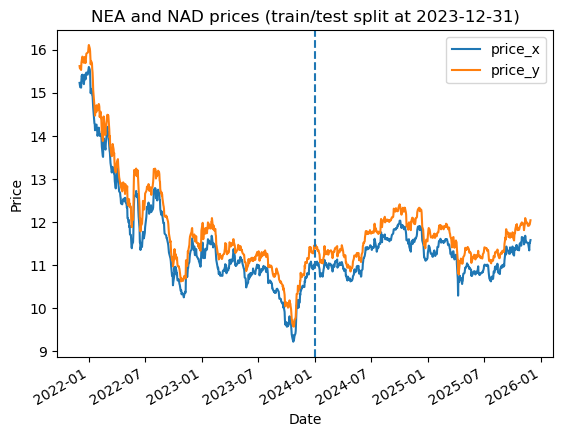

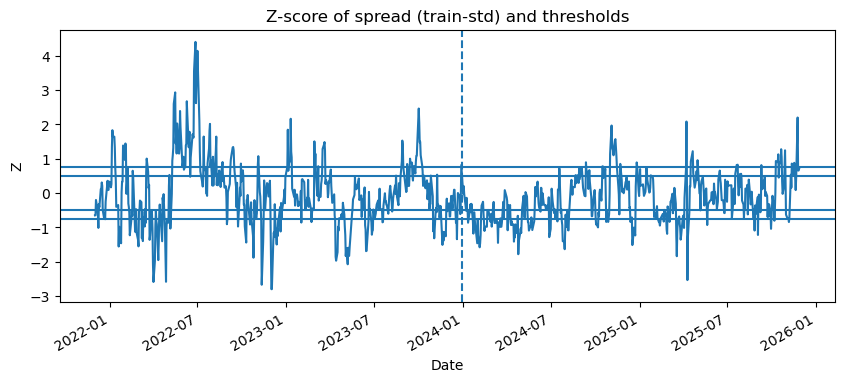

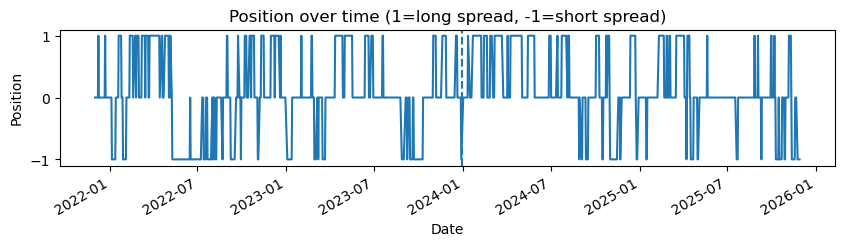

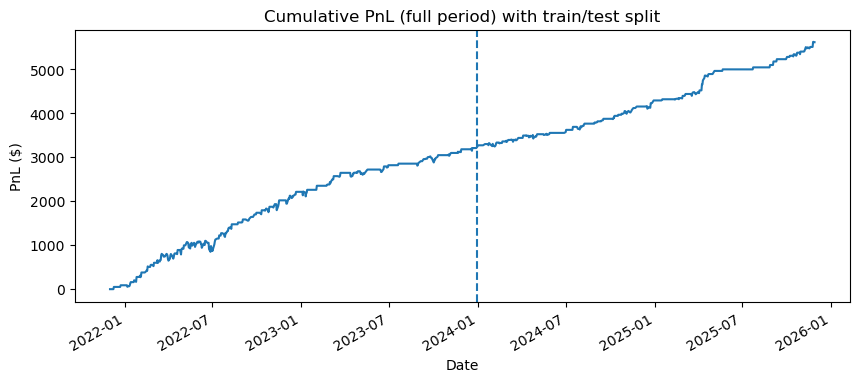

In [508]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ========= CONFIG =========
pair_s1 = "NEA"
pair_s2 = "NAD"

entry_z = 0.75   # enter when |z| > 2
exit_z  = 0.50   # exit when |z| < 0.5
notional = 10_000  # $10k notional per leg for scaling

train_end = "2023-12-31"  # train on 2022–2023, test on 2024+

# ========= BUILD SPREAD WITH TRAIN/TEST SPLIT =========

pair_prices = prices_clean[[pair_s1, pair_s2]].dropna().copy()

# train/test split by date
train_prices = pair_prices.loc[pair_prices.index < train_end]
test_prices  = pair_prices.loc[pair_prices.index >= train_end]

print("Train period:", train_prices.index.min(), "→", train_prices.index.max())
print("Test period :", test_prices.index.min(), "→", test_prices.index.max())

# 1) Estimate beta on TRAIN only (log prices)
log_x_train = np.log(train_prices[pair_s1])
log_y_train = np.log(train_prices[pair_s2])

X_train = sm.add_constant(log_x_train.values)
model_beta = sm.OLS(log_y_train.values, X_train).fit()
beta = model_beta.params[1]

print(f"Estimated beta on train: {beta:.4f}")

# 2) Build spread on FULL sample using train-estimated beta
log_x_full = np.log(pair_prices[pair_s1])
log_y_full = np.log(pair_prices[pair_s2])
spread_full = log_y_full - beta * log_x_full

# 3) Standardize using TRAIN mean and std
spread_train = spread_full.loc[train_prices.index]
spread_mean = spread_train.mean()
spread_std  = spread_train.std()

z_full = (spread_full - spread_mean) / spread_std

df = pd.DataFrame({
    "price_x": pair_prices[pair_s1],
    "price_y": pair_prices[pair_s2],
    "spread": spread_full,
    "z": z_full
})

# ========= SIGNALS (APPLIED TO FULL SERIES, BUT WE'LL SCORE TEST ONLY) =========
state = 0  # 0 = flat, 1 = long spread, -1 = short spread
positions = []

for t, row in df.iterrows():
    z_t = row["z"]

    if state == 0:
        if z_t > entry_z:
            state = -1  # short spread: short y, long x
        elif z_t < -entry_z:
            state = 1   # long spread: long y, short x
    else:
        # in a trade; exit when z comes back near 0
        if abs(z_t) < exit_z:
            state = 0

    positions.append(state)

df["position"] = positions

# ========= P&L =========
ret_x = df["price_x"].pct_change().fillna(0.0)
ret_y = df["price_y"].pct_change().fillna(0.0)

w_y = df["position"] * (notional / df["price_y"])
w_x = -df["position"] * beta * (notional / df["price_x"])

pnl = w_x.shift(1) * (df["price_x"] - df["price_x"].shift(1)) + \
      w_y.shift(1) * (df["price_y"] - df["price_y"].shift(1))

df["pnl"] = pnl.fillna(0.0)
df["cum_pnl"] = df["pnl"].cumsum()

# ========= PERFORMANCE TABLES: TRAIN vs TEST vs FULL =========
def perf_stats(sub):
    total_pnl = sub["pnl"].sum()
    avg_daily_pnl = sub["pnl"].mean()
    daily_pnl_std = sub["pnl"].std()
    sharpe = np.nan
    if daily_pnl_std > 0:
        sharpe = (avg_daily_pnl / daily_pnl_std) * np.sqrt(252)
    trades = (sub["position"].diff().abs() > 0).sum() / 2

    return {
        "total_pnl": total_pnl,
        "avg_daily_pnl": avg_daily_pnl,
        "daily_pnl_std": daily_pnl_std,
        "sharpe": sharpe,
        "trades": trades
    }

df_train = df.loc[df.index < train_end]
df_test  = df.loc[df.index >= train_end]
df_full  = df.copy()

summary = pd.DataFrame({
    "train": perf_stats(df_train),
    "test": perf_stats(df_test),
    "full": perf_stats(df_full)
}).T

print("\nPerformance summary (notional = $10k per leg):")
print(summary)

# ========= SIMPLE TABLE OF LAST FEW ROWS =========
print("\nTail of trading dataframe:")
print(df[["price_x", "price_y", "z", "position", "pnl", "cum_pnl"]].tail())

# ========= PLOTS =========

# 1) Prices
plt.figure(figsize=(10, 4))
df[["price_x", "price_y"]].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title(f"{pair_s1} and {pair_s2} prices (train/test split at {train_end})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# 2) Z-score and position
plt.figure(figsize=(10, 4))
df["z"].plot()
plt.axhline(entry_z)
plt.axhline(-entry_z)
plt.axhline(exit_z)
plt.axhline(-exit_z)
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title(f"Z-score of spread (train-std) and thresholds")
plt.xlabel("Date")
plt.ylabel("Z")
plt.show()

plt.figure(figsize=(10, 2))
df["position"].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title("Position over time (1=long spread, -1=short spread)")
plt.xlabel("Date")
plt.ylabel("Position")
plt.show()

# 3) Cumulative PnL
plt.figure(figsize=(10, 4))
df["cum_pnl"].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title("Cumulative PnL (full period) with train/test split")
plt.xlabel("Date")
plt.ylabel("PnL ($)")
plt.show()


In [509]:
import statsmodels.api as sm

def backtest_pair(
    s1, s2,
    prices_clean,
    train_end="2023-12-31",
    entry_z=0.75,
    exit_z=0.50,
    notional=10_000
):
    pair_prices = prices_clean[[s1, s2]].dropna().copy()
    if pair_prices.empty:
        return None

    train_prices = pair_prices.loc[pair_prices.index < train_end]
    test_prices  = pair_prices.loc[pair_prices.index >= train_end]

    if len(train_prices) < 100 or len(test_prices) < 30:
        return None

    # beta on TRAIN
    log_x_train = np.log(train_prices[s1])
    log_y_train = np.log(train_prices[s2])

    X_train = sm.add_constant(log_x_train.values)
    model_beta = sm.OLS(log_y_train.values, X_train).fit()
    beta = model_beta.params[1]

    # spread on FULL sample
    log_x_full = np.log(pair_prices[s1])
    log_y_full = np.log(pair_prices[s2])
    spread_full = log_y_full - beta * log_x_full

    # z-score using TRAIN mean/std
    spread_train = spread_full.loc[train_prices.index]
    spread_mean = spread_train.mean()
    spread_std  = spread_train.std()

    z_full = (spread_full - spread_mean) / spread_std

    df = pd.DataFrame({
        "price_x": pair_prices[s1],
        "price_y": pair_prices[s2],
        "spread": spread_full,
        "z": z_full
    })

    # signals
    state = 0
    positions = []

    for t, row in df.iterrows():
        z_t = row["z"]
        if state == 0:
            if z_t > entry_z:
                state = -1
            elif z_t < -entry_z:
                state = 1
        else:
            if abs(z_t) < exit_z:
                state = 0
        positions.append(state)

    df["position"] = positions

    # PnL
    ret_x = df["price_x"].pct_change().fillna(0.0)
    ret_y = df["price_y"].pct_change().fillna(0.0)

    w_y = df["position"] * (notional / df["price_y"])
    w_x = -df["position"] * beta * (notional / df["price_x"])

    pnl = w_x.shift(1) * (df["price_x"] - df["price_x"].shift(1)) + \
          w_y.shift(1) * (df["price_y"] - df["price_y"].shift(1))

    df["pnl"] = pnl.fillna(0.0)
    df["cum_pnl"] = df["pnl"].cumsum()
    df["pair"] = f"{s1}_{s2}"

    return df


In [510]:
# Ensure tradable pairs are consistent with current prices_clean universe
valid_syms = set(prices_clean.columns)

tradable = tradable[
    tradable["s1"].isin(valid_syms) &
    tradable["s2"].isin(valid_syms)
].reset_index(drop=True)

print(f"Number of tradable pairs after syncing with prices_clean: {len(tradable)}")

Number of tradable pairs after syncing with prices_clean: 42


In [511]:
pair_results = []
for _, row in tradable.iterrows():
    s1, s2 = row["s1"], row["s2"]
    df_pair = backtest_pair(s1, s2, prices_clean)
    if df_pair is not None:
        pair_results.append(df_pair)

# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

# Equal capital per pair basket PnL
basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

basket_stats = {
    "total_pnl": basket_cum_pnl.iloc[-1],
    "avg_daily_pnl": basket_pnl.mean(),
    "daily_pnl_std": basket_pnl.std(),
}
basket_stats["sharpe"] = (
    basket_stats["avg_daily_pnl"] / basket_stats["daily_pnl_std"] * np.sqrt(252)
    if basket_stats["daily_pnl_std"] > 0 else np.nan
)

# ---- Turn into a clean table ----
basket_summary = (
    pd.DataFrame([basket_stats], index=["basket"])
      .rename(columns={
          "total_pnl": "Total PnL ($)",
          "avg_daily_pnl": "Avg Daily PnL ($)",
          "daily_pnl_std": "Daily PnL Std ($)",
          "sharpe": "Sharpe (ann.)"
      })
      .round(2)
)

print("Basket performance summary:")
display(basket_summary)  # in Jupyter; or just print(basket_summary) if not using display()

# Optional: peek at the cumulative PnL series
basket_cum_pnl.name = "basket_cum_pnl"
print("\nCumulative PnL (last 5 days):")
print(basket_cum_pnl.tail())


Basket performance summary:


,Total PnL ($),Avg Daily PnL ($),Daily PnL Std ($),Sharpe (ann.)
basket,271258.09,270.45,965.53,4.45



Cumulative PnL (last 5 days):
timestamp
2025-11-21 05:00:00+00:00    272682.095287
2025-11-24 05:00:00+00:00    272503.403459
2025-11-25 05:00:00+00:00    271568.402955
2025-11-26 05:00:00+00:00    271178.393866
2025-11-28 05:00:00+00:00    271258.086259
Name: basket_cum_pnl, dtype: float64


In [512]:
# Make sure this matches what you used in backtest_pair
train_end = "2023-12-31"

def perf_stats_from_df(sub: pd.DataFrame):
    """Compute simple performance stats from a pair-level df slice."""
    if sub.empty:
        return {
            "total_pnl": np.nan,
            "avg_daily_pnl": np.nan,
            "daily_pnl_std": np.nan,
            "sharpe": np.nan,
            "trades": np.nan,
        }

    total_pnl = sub["pnl"].sum()
    avg_daily_pnl = sub["pnl"].mean()
    daily_pnl_std = sub["pnl"].std()

    if daily_pnl_std > 0:
        sharpe = (avg_daily_pnl / daily_pnl_std) * np.sqrt(252)
    else:
        sharpe = np.nan

    trades = (sub["position"].diff().abs() > 0).sum() / 2

    return {
        "total_pnl": total_pnl,
        "avg_daily_pnl": avg_daily_pnl,
        "daily_pnl_std": daily_pnl_std,
        "sharpe": sharpe,
        "trades": trades,
    }

pair_rows = []

for df_pair in pair_results:
    pair_name = df_pair["pair"].iloc[0]

    df_train = df_pair.loc[df_pair.index < train_end]
    df_test  = df_pair.loc[df_pair.index >= train_end]
    df_full  = df_pair

    stats_train = perf_stats_from_df(df_train)
    stats_test  = perf_stats_from_df(df_test)
    stats_full  = perf_stats_from_df(df_full)

    row = {
        "pair": pair_name,

        # FULL period
        "full_total_pnl": stats_full["total_pnl"],
        "full_sharpe": stats_full["sharpe"],
        "full_trades": stats_full["trades"],

        # TRAIN (2022–2023)
        "train_total_pnl": stats_train["total_pnl"],
        "train_sharpe": stats_train["sharpe"],
        "train_trades": stats_train["trades"],

        # TEST (2024+)
        "test_total_pnl": stats_test["total_pnl"],
        "test_sharpe": stats_test["sharpe"],
        "test_trades": stats_test["trades"],
    }

    pair_rows.append(row)

pair_perf = pd.DataFrame(pair_rows).set_index("pair")

# Sort by test Sharpe (out-of-sample) to see which pairs generalize best
pair_perf_sorted = pair_perf.sort_values("test_sharpe", ascending=False)

# Clean up formatting a bit
pair_perf_display = pair_perf_sorted.round(2)

print("Per-pair performance (sorted by test Sharpe):")
display(pair_perf_display.head(20))  # top 20; change as you like


Per-pair performance (sorted by test Sharpe):


,full_total_pnl,full_sharpe,full_trades,train_total_pnl,train_sharpe,train_trades,test_total_pnl,test_sharpe,test_trades
pair,,,,,,,,,
NEA_NAD,5614.13,3.23,97.5,3208.04,2.97,52.5,2406.09,3.92,44.5
VKQ_VMO,6755.82,3.19,87.5,4401.82,3.68,52.0,2354.00,2.58,35.5
NEA_NVG,5577.14,2.54,51.0,3799.01,2.81,32.0,1778.12,2.25,19.0
USB_KEY,13364.08,1.77,31.0,7113.25,1.54,17.5,6250.82,2.21,13.5
CTBB_CTDD,11318.67,2.40,66.5,7198.76,2.90,40.5,4119.91,1.85,26.0
NZF_NVG,4193.63,2.01,37.5,2648.25,2.17,21.0,1545.38,1.83,16.5
NVG_NAD,4750.42,2.51,49.0,3442.51,3.05,32.5,1307.91,1.78,16.0
CCL_CUK,3913.81,1.92,49.5,2469.24,2.08,28.5,1444.57,1.74,21.0
SOJD_SOJE,5139.24,1.88,29.5,3163.33,2.02,17.0,1975.91,1.71,12.5


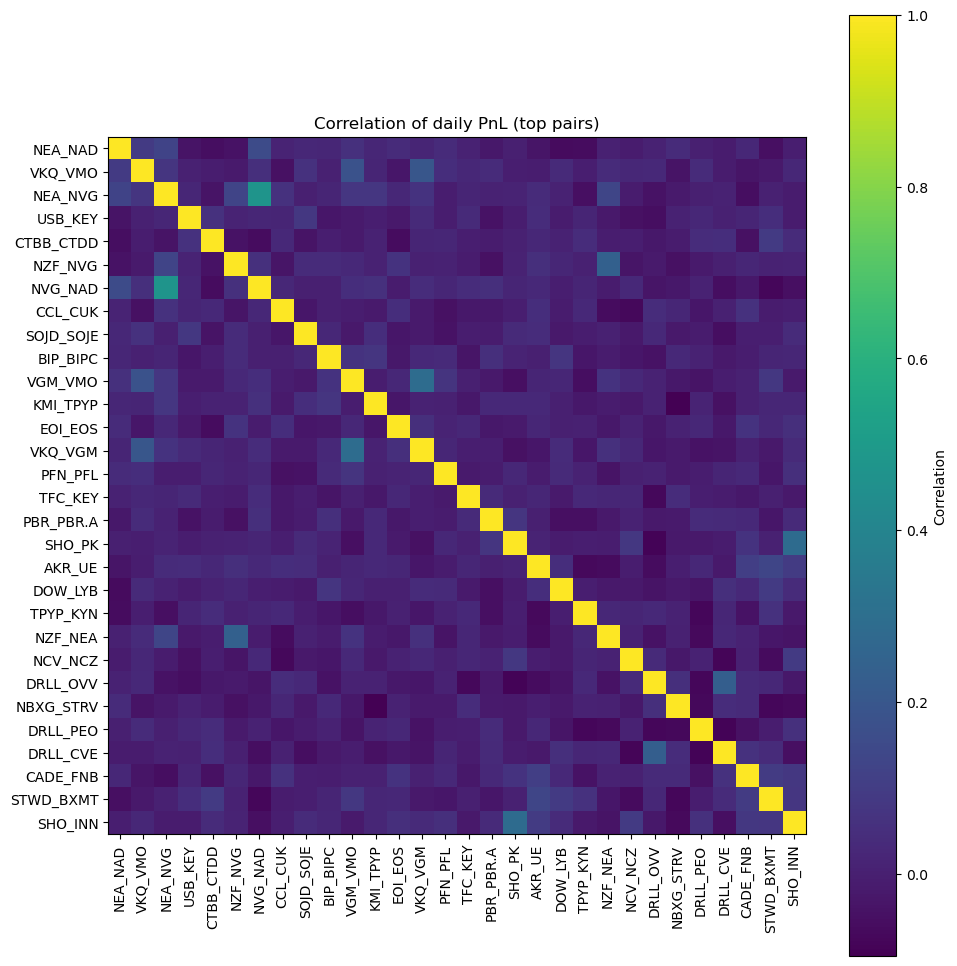

In [513]:
# all_pnl: index = date, columns = pair names, values = daily PnL per pair

# Correlation matrix of pair PnLs
pair_corr = all_pnl.corr()

#print("Correlation matrix of pair daily PnL:")
#display(pair_corr.round(2))

# e.g., top X pairs by test Sharpe
top_n = 30
top_pairs = pair_perf_sorted.head(top_n).index.tolist()

sub_pnl = all_pnl[top_pairs]
pair_corr_top = sub_pnl.corr()

plt.figure(figsize=(10, 10))
im = plt.imshow(pair_corr_top, interpolation="nearest")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(top_pairs)), top_pairs, rotation=90)
plt.yticks(range(len(top_pairs)), top_pairs)
plt.title("Correlation of daily PnL (top pairs)")
plt.tight_layout()
plt.show()


Factoring in Market Frictions

In [514]:
def backtest_pair(
    s1, s2,
    prices_clean,
    train_end="2023-12-31",
    entry_z=0.75,
    exit_z=0.50,
    notional=10_000,
    cost_bps=2e-4,      # 2 bps per dollar traded (0.02%)
    borrow_rate=0.03    # 3% annualized borrow on the short leg
):
    """
    Backtest a single cointegrated pair with train/test split and frictions.

    - Train beta on data before train_end.
    - Build spread & z-score using train stats.
    - Trade on full period with:
        * Transaction costs on traded notional.
        * Borrow cost on short notional.
    """

    pair_prices = prices_clean[[s1, s2]].dropna().copy()
    if pair_prices.empty:
        return None

    # --- Train / test split ---
    train_prices = pair_prices.loc[pair_prices.index < train_end]
    test_prices  = pair_prices.loc[pair_prices.index >= train_end]

    # Need enough data
    if len(train_prices) < 100 or len(test_prices) < 30:
        return None

    # --- Estimate beta on TRAIN (log prices) ---
    log_x_train = np.log(train_prices[s1])
    log_y_train = np.log(train_prices[s2])

    X_train = sm.add_constant(log_x_train.values)
    model_beta = sm.OLS(log_y_train.values, X_train).fit()
    beta = model_beta.params[1]

    # --- Build spread on FULL sample ---
    log_x_full = np.log(pair_prices[s1])
    log_y_full = np.log(pair_prices[s2])
    spread_full = log_y_full - beta * log_x_full

    # --- Z-score using TRAIN mean/std ---
    spread_train = spread_full.loc[train_prices.index]
    spread_mean = spread_train.mean()
    spread_std  = spread_train.std()

    z_full = (spread_full - spread_mean) / spread_std

    df = pd.DataFrame({
        "price_x": pair_prices[s1],
        "price_y": pair_prices[s2],
        "spread": spread_full,
        "z": z_full
    })

    # --- Signals (same logic as before) ---
    state = 0  # 0 = flat, 1 = long spread, -1 = short spread
    positions = []

    for t, row in df.iterrows():
        z_t = row["z"]

        if state == 0:
            if z_t > entry_z:
                state = -1  # short spread: short y, long x
            elif z_t < -entry_z:
                state = 1   # long spread: long y, short x
        else:
            if abs(z_t) < exit_z:
                state = 0

        positions.append(state)

    df["position"] = positions

    # --- Position sizing (shares) ---
    ret_x = df["price_x"].pct_change().fillna(0.0)
    ret_y = df["price_y"].pct_change().fillna(0.0)

    # For state = 1 (long spread): long y, short x
    # For state = -1 (short spread): short y, long x
    w_y = df["position"] * (notional / df["price_y"])
    w_x = -df["position"] * beta * (notional / df["price_x"])

    # Previous day positions: used for PnL and borrow
    w_x_prev = w_x.shift(1)
    w_y_prev = w_y.shift(1)

    # --- Raw PnL from price moves ---
    raw_pnl = (
        w_x_prev * (df["price_x"] - df["price_x"].shift(1)) +
        w_y_prev * (df["price_y"] - df["price_y"].shift(1))
    )

    # --- Transaction costs on traded notional ---
    delta_x = (w_x - w_x_prev).abs()
    delta_y = (w_y - w_y_prev).abs()

    traded_notional = delta_x * df["price_x"] + delta_y * df["price_y"]
    tcost = cost_bps * traded_notional

    # --- Borrow cost on the short leg ---
    # If position = 1 (long spread): short x
    # If position = -1 (short spread): short y
    short_notional = np.where(
        df["position"] == 1,
        (w_x_prev.abs() * df["price_x"]),            # short x
        np.where(
            df["position"] == -1,
            (w_y_prev.abs() * df["price_y"]),        # short y
            0.0
        )
    )

    daily_borrow = borrow_rate / 252.0
    borrow_cost = daily_borrow * short_notional

    # --- Net PnL with frictions ---
    df["pnl"] = (raw_pnl - tcost - borrow_cost).fillna(0.0)
    df["cum_pnl"] = df["pnl"].cumsum()
    df["pair"] = f"{s1}_{s2}"

    return df


In [515]:
pair_results = []
for _, row in tradable.iterrows():
    s1, s2 = row["s1"], row["s2"]
    df_pair = backtest_pair(s1, s2, prices_clean)
    if df_pair is not None:
        pair_results.append(df_pair)

# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

# Equal capital per pair basket PnL
basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

basket_stats = {
    "total_pnl": basket_cum_pnl.iloc[-1],
    "avg_daily_pnl": basket_pnl.mean(),
    "daily_pnl_std": basket_pnl.std(),
}
basket_stats["sharpe"] = (
    basket_stats["avg_daily_pnl"] / basket_stats["daily_pnl_std"] * np.sqrt(252)
    if basket_stats["daily_pnl_std"] > 0 else np.nan
)

# ---- Turn into a clean table ----
basket_summary = (
    pd.DataFrame([basket_stats], index=["basket"])
      .rename(columns={
          "total_pnl": "Total PnL ($)",
          "avg_daily_pnl": "Avg Daily PnL ($)",
          "daily_pnl_std": "Daily PnL Std ($)",
          "sharpe": "Sharpe (ann.)"
      })
      .round(2)
)

print("Basket performance summary:")
display(basket_summary)  # in Jupyter; or just print(basket_summary) if not using display()

# Optional: peek at the cumulative PnL series
basket_cum_pnl.name = "basket_cum_pnl"
print("\nCumulative PnL (last 5 days):")
print(basket_cum_pnl.tail())

Basket performance summary:


,Total PnL ($),Avg Daily PnL ($),Daily PnL Std ($),Sharpe (ann.)
basket,225603.25,224.93,965.34,3.7



Cumulative PnL (last 5 days):
timestamp
2025-11-21 05:00:00+00:00    227259.397216
2025-11-24 05:00:00+00:00    227014.874517
2025-11-25 05:00:00+00:00    226020.728434
2025-11-26 05:00:00+00:00    225579.479400
2025-11-28 05:00:00+00:00    225603.247652
Name: basket_cum_pnl, dtype: float64


Risk Control here: Will Need Fixed Later

In [516]:
def apply_drawdown_pct_kill(
    df_pair: pd.DataFrame,
    max_dd_pct: float = 0.10,   # 10% max drawdown
    base_capital: float = 10_000.0,
):
    """
    Apply a percentage max drawdown kill switch per pair.

    - Equity curve = base_capital + cumulative PnL
    - Drawdown % = (equity - peak_equity) / peak_equity
    - If drawdown <= -max_dd_pct, kill the strategy from the NEXT day onward.
    """
    df = df_pair.copy()

    # Equity curve
    cum_pnl = df["pnl"].cumsum()
    equity = base_capital + cum_pnl

    # Running peak equity
    peak_equity = equity.cummax()

    # Drawdown percentage (negative when below peak)
    drawdown_pct = (equity - peak_equity) / peak_equity

    # First time drawdown breaches limit
    hit = drawdown_pct <= -max_dd_pct
    if hit.any():
        first_hit_date = hit[hit].index[0]

        # From the NEXT day onward, flatten and zero PnL
        mask_after = df.index > first_hit_date
        df.loc[mask_after, "position"] = 0.0
        df.loc[mask_after, "pnl"] = 0.0

    # Recompute cumulative PnL after applying the kill switch
    df["cum_pnl"] = df["pnl"].cumsum()
    df["drawdown_pct"] = drawdown_pct

    return df


In [517]:
notional = 10_000.0          # same notional as in backtest_pair
max_pair_dd_pct = 0.10       # kill after 10% drawdown from peak equity

pair_results = []
for _, row in tradable.iterrows():
    s1, s2 = row["s1"], row["s2"]
    df_pair = backtest_pair(
        s1, s2,
        prices_clean=prices_clean,
        train_end="2023-12-31",  # same as selection
        entry_z=0.75,
        exit_z=0.25,
        notional=notional,
        cost_bps=3e-4,
        borrow_rate=0.03,
    )
    if df_pair is not None:
        df_pair = apply_drawdown_pct_kill(
            df_pair,
            max_dd_pct=max_pair_dd_pct,
            base_capital=notional,
        )
        pair_results.append(df_pair)


In [518]:
# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

train_end = "2023-12-31"
basket_pnl_train = basket_pnl.loc[basket_pnl.index < train_end]
basket_pnl_test  = basket_pnl.loc[basket_pnl.index >= train_end]

def basket_stats_from_series(pnl: pd.Series, label: str):
    if pnl.empty:
        return pd.Series(
            [np.nan, np.nan, np.nan, np.nan],
            index=["Total PnL ($)", "Avg Daily PnL ($)", "Daily PnL Std ($)", "Sharpe (ann.)"],
            name=label,
        )
    total = pnl.sum()
    avg = pnl.mean()
    std = pnl.std()
    sharpe = (avg / std) * np.sqrt(252) if std > 0 else np.nan
    return pd.Series(
        [total, avg, std, sharpe],
        index=["Total PnL ($)", "Avg Daily PnL ($)", "Daily PnL Std ($)", "Sharpe (ann.)"],
        name=label,
    )

basket_summary = pd.concat(
    [
        basket_stats_from_series(basket_pnl_train, "train"),
        basket_stats_from_series(basket_pnl_test, "test"),
        basket_stats_from_series(basket_pnl, "full"),
    ],
    axis=1
).T.round(2)

print("Basket performance summary (with frictions, TRAIN-selected pairs):")
display(basket_summary)

print("\nCumulative basket PnL (last 5 days):")
print(basket_cum_pnl.tail())


Basket performance summary (with frictions, TRAIN-selected pairs):


,Total PnL ($),Avg Daily PnL ($),Daily PnL Std ($),Sharpe (ann.)
train,105654.61,202.02,586.57,5.47
test,18711.37,38.98,300.55,2.06
full,124365.98,123.99,478.61,4.11



Cumulative basket PnL (last 5 days):
timestamp
2025-11-21 05:00:00+00:00    123571.768025
2025-11-24 05:00:00+00:00    124101.309322
2025-11-25 05:00:00+00:00    124469.553638
2025-11-26 05:00:00+00:00    124236.242861
2025-11-28 05:00:00+00:00    124365.984284
dtype: float64


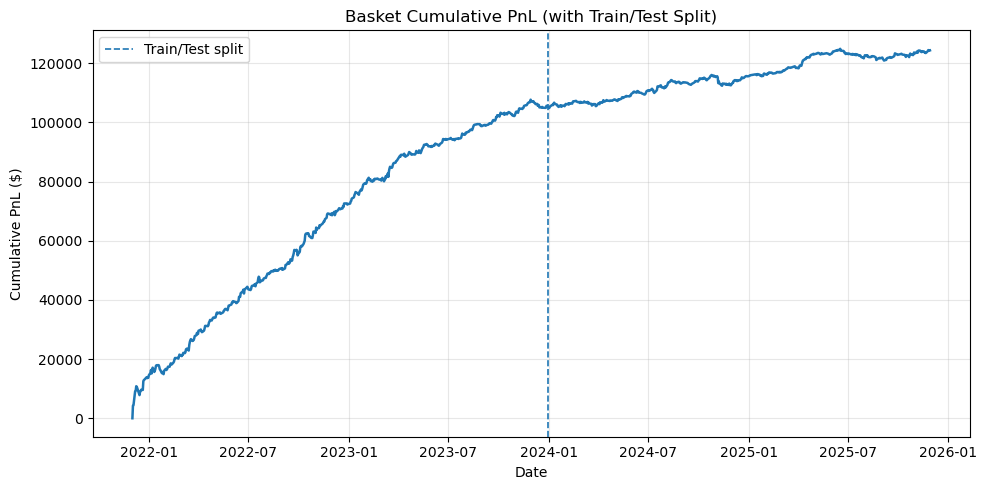

In [519]:
# If not already computed:
# basket_pnl = all_pnl.sum(axis=1)
# basket_cum_pnl = basket_pnl.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(basket_cum_pnl.index, basket_cum_pnl.values, linewidth=1.8)

# Mark the train/test split
split_date = pd.to_datetime(train_end)
plt.axvline(split_date, linestyle="--", linewidth=1.2, label="Train/Test split")

plt.title("Basket Cumulative PnL (with Train/Test Split)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [520]:
pair_rows = []
train_end = "2023-12-31"

for df_pair in pair_results:
    pair_name = df_pair["pair"].iloc[0]

    df_train = df_pair.loc[df_pair.index < train_end]
    df_test  = df_pair.loc[df_pair.index >= train_end]
    df_full  = df_pair

    stats_train = perf_stats_from_df(df_train)
    stats_test  = perf_stats_from_df(df_test)
    stats_full  = perf_stats_from_df(df_full)

    row = {
        "pair": pair_name,

        "full_total_pnl": stats_full["total_pnl"],
        "full_sharpe": stats_full["sharpe"],
        "full_trades": stats_full["trades"],

        "train_total_pnl": stats_train["total_pnl"],
        "train_sharpe": stats_train["sharpe"],
        "train_trades": stats_train["trades"],

        "test_total_pnl": stats_test["total_pnl"],
        "test_sharpe": stats_test["sharpe"],
        "test_trades": stats_test["trades"],
    }

    pair_rows.append(row)

pair_perf = pd.DataFrame(pair_rows).set_index("pair")

# Sort by test Sharpe to see who really works OOS
pair_perf_sorted = pair_perf.sort_values("test_sharpe", ascending=False)
pair_perf_display = pair_perf_sorted.round(2)

print("Per-pair performance (sorted by TEST Sharpe):")
display(pair_perf_display)


Per-pair performance (sorted by TEST Sharpe):


,full_total_pnl,full_sharpe,full_trades,train_total_pnl,train_sharpe,train_trades,test_total_pnl,test_sharpe,test_trades
pair,,,,,,,,,
NEA_NAD,3364.27,1.74,69.5,1750.58,1.49,37.5,1613.70,2.24,31.5
NEA_NVG,5028.38,2.16,42.0,3666.06,2.59,28.0,1362.32,1.57,14.0
SOJD_SOJE,4700.14,1.64,24.5,2855.20,1.73,14.0,1844.93,1.53,10.5
VKQ_VMO,4112.15,1.75,59.5,2697.26,2.00,35.0,1414.90,1.43,24.5
KMI_TPYP,3480.59,1.17,21.0,1766.81,1.20,11.0,1713.78,1.14,10.0
BIP_BIPC,8215.95,1.30,22.0,4990.39,1.46,13.0,3225.56,1.11,9.0
CTBB_CTDD,8064.19,1.63,50.5,5516.37,2.10,32.5,2547.82,1.10,18.0
NVG_NAD,3191.31,1.52,31.0,2376.89,1.85,20.5,814.41,1.05,10.0
CCL_CUK,2419.54,1.13,35.5,1676.40,1.35,22.5,743.14,0.83,13.0


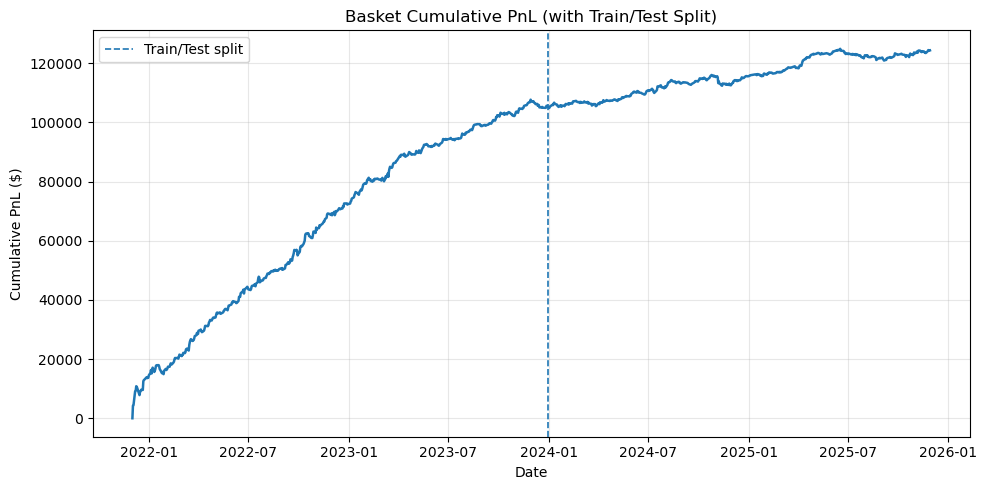

In [521]:
# If not already computed:
# basket_pnl = all_pnl.sum(axis=1)
# basket_cum_pnl = basket_pnl.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(basket_cum_pnl.index, basket_cum_pnl.values, linewidth=1.8)

# Mark the train/test split
split_date = pd.to_datetime(train_end)
plt.axvline(split_date, linestyle="--", linewidth=1.2, label="Train/Test split")

plt.title("Basket Cumulative PnL (with Train/Test Split)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [522]:
# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

train_end = "2023-12-31"
basket_pnl_train = basket_pnl.loc[basket_pnl.index < train_end]
basket_pnl_test  = basket_pnl.loc[basket_pnl.index >= train_end]

def basket_stats_from_series(pnl: pd.Series, label: str) -> pd.Series:
    if pnl.empty:
        return pd.Series(
            {
                "label": label,
                "total_pnl": np.nan,
                "avg_daily_pnl": np.nan,
                "daily_pnl_std": np.nan,
                "sharpe": np.nan,
                "n_days": 0,
            }
        )
    total = pnl.sum()
    avg   = pnl.mean()
    std   = pnl.std()
    sharpe = (avg / std) * np.sqrt(252) if std > 0 else np.nan

    return pd.Series(
        {
            "label": label,
            "total_pnl": total,
            "avg_daily_pnl": avg,
            "daily_pnl_std": std,
            "sharpe": sharpe,
            "n_days": len(pnl),
        }
    )

basket_summary = pd.concat(
    [
        basket_stats_from_series(basket_pnl_train, "train"),
        basket_stats_from_series(basket_pnl_test,  "test"),
        basket_stats_from_series(basket_pnl,       "full"),
    ],
    axis=1
).T.round(2)

print("Basket performance summary (with frictions, TRAIN-selected pairs):")
display(basket_summary)

print("\nCumulative basket PnL (last 5 days):")
print(basket_cum_pnl.tail())


Basket performance summary (with frictions, TRAIN-selected pairs):


,label,total_pnl,avg_daily_pnl,daily_pnl_std,sharpe,n_days
0,train,105654.610762,202.016464,586.573684,5.467194,523
1,test,18711.373523,38.982028,300.551247,2.058952,480
2,full,124365.984284,123.994002,478.609482,4.11263,1003



Cumulative basket PnL (last 5 days):
timestamp
2025-11-21 05:00:00+00:00    123571.768025
2025-11-24 05:00:00+00:00    124101.309322
2025-11-25 05:00:00+00:00    124469.553638
2025-11-26 05:00:00+00:00    124236.242861
2025-11-28 05:00:00+00:00    124365.984284
dtype: float64


In [523]:
pair_rows = []
train_end = "2023-12-31"

for df in pair_results:
    pair_name = df["pair"].iloc[0]

    train_sub = df.loc[df.index < train_end]
    test_sub  = df.loc[df.index >= train_end]

    stats_train = perf_stats_from_df(train_sub)
    stats_test  = perf_stats_from_df(test_sub)

    row = {
        "pair": pair_name,
        "train_total_pnl": stats_train["total_pnl"],
        "train_sharpe":    stats_train["sharpe"],
        "train_trades":    stats_train["trades"],
        "test_total_pnl":  stats_test["total_pnl"],
        "test_sharpe":     stats_test["sharpe"],
        "test_trades":     stats_test["trades"],
    }

    pair_rows.append(row)

pair_perf = pd.DataFrame(pair_rows).set_index("pair")

# Sort by test Sharpe to see who really works OOS
pair_perf_sorted  = pair_perf.sort_values("test_sharpe", ascending=False)
pair_perf_display = pair_perf_sorted.round(2)

print("Per-pair performance (sorted by TEST Sharpe):")
display(pair_perf_display)


Per-pair performance (sorted by TEST Sharpe):


,train_total_pnl,train_sharpe,train_trades,test_total_pnl,test_sharpe,test_trades
pair,,,,,,
NEA_NAD,1750.58,1.49,37.5,1613.70,2.24,31.5
NEA_NVG,3666.06,2.59,28.0,1362.32,1.57,14.0
SOJD_SOJE,2855.20,1.73,14.0,1844.93,1.53,10.5
VKQ_VMO,2697.26,2.00,35.0,1414.90,1.43,24.5
KMI_TPYP,1766.81,1.20,11.0,1713.78,1.14,10.0
BIP_BIPC,4990.39,1.46,13.0,3225.56,1.11,9.0
CTBB_CTDD,5516.37,2.10,32.5,2547.82,1.10,18.0
NVG_NAD,2376.89,1.85,20.5,814.41,1.05,10.0
CCL_CUK,1676.40,1.35,22.5,743.14,0.83,13.0


In [524]:
# Make sure this matches your backtest
train_end   = "2023-12-31"
cost_bps    = 2e-4    # 2 bps
borrow_rate = 0.03
notional    = 10_000

entry_z_list = [0.75, 1.0, 1.25]
exit_z_list  = [0.25, 0.50, 0.75]

rows = []

def basket_stats(pnl: pd.Series) -> dict:
    """Compute stats for a test-period basket PnL series."""
    if pnl.empty:
        return {
            "total_pnl": np.nan,
            "avg_daily_pnl": np.nan,
            "daily_pnl_std": np.nan,
            "sharpe": np.nan,
            "n_days": 0,
        }
    total = pnl.sum()
    avg   = pnl.mean()
    std   = pnl.std()
    sharpe = (avg / std) * np.sqrt(252) if std > 0 else np.nan

    return {
        "total_pnl": total,
        "avg_daily_pnl": avg,
        "daily_pnl_std": std,
        "sharpe": sharpe,
        "n_days": len(pnl),
    }


for entry_z in entry_z_list:
    for exit_z in exit_z_list:
        # sensible: exit threshold should be below entry threshold
        if exit_z >= entry_z:
            continue

        # 1) run all tradable pairs with this entry/exit setup
        pair_pnls_test = []

        for _, row in tradable.iterrows():
            s1, s2 = row["s1"], row["s2"]

            df_pair = backtest_pair(
                s1, s2,
                prices_clean=prices_clean,
                train_end=train_end,
                entry_z=entry_z,
                exit_z=exit_z,
                notional=notional,
                cost_bps=cost_bps,
                borrow_rate=borrow_rate,
            )

            if df_pair is None:
                continue

            # apply kill switch if desired
            df_pair = apply_cum_loss_kill(df_pair, max_cum_loss=max_pair_cum_loss)

            # keep only TEST-period PnL
            pnl_test = df_pair.loc[df_pair.index >= train_end, "pnl"]
            if pnl_test.empty:
                continue

            pair_name = df_pair["pair"].iloc[0]
            pair_pnls_test.append(pnl_test.rename(pair_name))

        if not pair_pnls_test:
            # no usable pairs for this parameter combo
            rows.append({
                "entry_z": entry_z,
                "exit_z": exit_z,
                "n_pairs": 0,
                "total_pnl": np.nan,
                "avg_daily_pnl": np.nan,
                "daily_pnl_std": np.nan,
                "sharpe": np.nan,
                "n_days": 0,
            })
            continue

        # 2) build test-period basket PnL from those pairs
        all_pnl_test = pd.concat(pair_pnls_test, axis=1).fillna(0.0)
        basket_pnl_test = all_pnl_test.sum(axis=1)

        stats = basket_stats(basket_pnl_test)
        stats["entry_z"] = entry_z
        stats["exit_z"]  = exit_z
        stats["n_pairs"] = len(pair_pnls_test)

        rows.append(stats)

grid_results = (
    pd.DataFrame(rows)
      .set_index(["entry_z", "exit_z"])
      .sort_values("sharpe", ascending=False)
)

grid_results_rounded = grid_results[[
    "n_pairs", "total_pnl", "avg_daily_pnl", "daily_pnl_std", "sharpe", "n_days"
]].round(3)

print("Test-period basket performance across (entry_z, exit_z) grid:")
display(grid_results_rounded)


Test-period basket performance across (entry_z, exit_z) grid:


n_pairs  total_pnl  avg_daily_pnl  daily_pnl_std  sharpe  \
entry_z exit_z                                                             
1.00    0.75         42  34916.221         72.742        842.431   1.371   
0.75    0.50         42  30767.474         64.099        890.497   1.143   
1.00    0.50         42  25853.036         53.860        783.831   1.091   
0.75    0.25         42  21381.518         44.545        709.958   0.996   
1.25    0.75         42  20126.321         41.930        756.833   0.879   
1.00    0.25         42  15721.297         32.753        694.598   0.749   
1.25    0.50         42  11684.289         24.342        809.797   0.477   
        0.25         42   6761.733         14.087        618.940   0.361   

                n_days  
entry_z exit_z          
1.00    0.75       480  
0.75    0.50       480  
1.00    0.50       480  
0.75    0.25       480  
1.25    0.75       480  
1.00    0.25       480  
1.25    0.50       480  
        0.25       480

In [525]:
# Capital invested (approx): 10k per pair
capital = len(pair_results) * 10_000

# Daily return of the strategy
strat_ret = basket_pnl / capital   # this is in decimal, e.g. 0.001 = 0.1%

# Optional: restrict to test sample only
train_end = "2023-12-31"
strat_ret_test = strat_ret.loc[strat_ret.index >= train_end]

In [526]:
path = r"C:\Users\Jonbf5\OneDrive - University of Cincinnati\Classes\FIN7053 Algorithmic Trading\F-F_Research_Data_5_Factors_2x3_daily.csv"

# Load, skipping the description header
ff5_raw = pd.read_csv(path, skiprows=3)
print(ff5_raw.head(5))

# 1) Rename first column to 'date'
ff5_raw = ff5_raw.rename(columns={"Unnamed: 0": "date"})

# 2) Convert date column to datetime, dropping footer lines
ff5_raw["date"] = pd.to_datetime(ff5_raw["date"], format="%Y%m%d", errors="coerce")

# Drop rows where conversion failed (NaT)
ff5_raw = ff5_raw.dropna(subset=["date"])

# 3) Set date as index
ff5 = ff5_raw.set_index("date")

# 4) Convert factors from percent to decimal
for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
    ff5[col] = ff5[col].astype(float) / 100.0

print(ff5.head())
print(ff5.index.min(), "→", ff5.index.max())


  Unnamed: 0  Mkt-RF   SMB   HML   RMW   CMA    RF
0   19630701   -0.67  0.00 -0.34 -0.01  0.16  0.01
1   19630702    0.79 -0.26  0.26 -0.07 -0.20  0.01
2   19630703    0.63 -0.17 -0.09  0.18 -0.34  0.01
3   19630705    0.40  0.08 -0.27  0.09 -0.34  0.01
4   19630708   -0.63  0.04 -0.18 -0.29  0.14  0.01
            Mkt-RF     SMB     HML     RMW     CMA      RF
date                                                      
1963-07-01 -0.0067  0.0000 -0.0034 -0.0001  0.0016  0.0001
1963-07-02  0.0079 -0.0026  0.0026 -0.0007 -0.0020  0.0001
1963-07-03  0.0063 -0.0017 -0.0009  0.0018 -0.0034  0.0001
1963-07-05  0.0040  0.0008 -0.0027  0.0009 -0.0034  0.0001
1963-07-08 -0.0063  0.0004 -0.0018 -0.0029  0.0014  0.0001
1963-07-01 00:00:00 → 2025-10-31 00:00:00


In [527]:
# 1) Start from your existing strat_ret
# strat_ret = basket_pnl / capital

strat_ret_aligned = strat_ret.copy()

# If strat_ret index is tz-aware, drop tz; then normalize to date
idx = strat_ret_aligned.index

# Drop timezone and keep just the date part
if getattr(idx, "tz", None) is not None:
    strat_ret_aligned.index = idx.tz_convert(None).normalize()
else:
    strat_ret_aligned.index = idx.normalize()

print("Strategy index sample:", strat_ret_aligned.index[:5])
print("FF5 index sample:", ff5.index[:5])


Strategy index sample: DatetimeIndex(['2021-12-01', '2021-12-02', '2021-12-03', '2021-12-06',
               '2021-12-07'],
              dtype='datetime64[ns]', name='timestamp', freq=None)
FF5 index sample: DatetimeIndex(['1963-07-01', '1963-07-02', '1963-07-03', '1963-07-05',
               '1963-07-08'],
              dtype='datetime64[ns]', name='date', freq=None)


In [528]:
# 2) Align on dates with inner join
data = pd.concat(
    [strat_ret_aligned.rename("strat_ret"), ff5],
    axis=1,
    join="inner"
).dropna()

print("Merged shape:", data.shape)
print(data.head())

# Sanity check: you should see both strat_ret and the factors in the same table

# 3) Excess return of strategy
data["strat_excess"] = data["strat_ret"] - data["RF"]

# 4) Prepare X and y
X = data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)

y = data["strat_excess"]

print("X shape:", X.shape, "y shape:", y.shape)  # should be (N, 6) and (N,)

# 5) Run Fama–French 5-factor regression
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model.summary())


Merged shape: (984, 7)
            strat_ret  Mkt-RF     SMB     HML     RMW     CMA   RF
2021-12-01   0.000000 -0.0159 -0.0044  0.0109  0.0233  0.0078  0.0
2021-12-02   0.010184  0.0153  0.0100  0.0124 -0.0066  0.0004  0.0
2021-12-03   0.000385 -0.0118 -0.0087  0.0108  0.0176  0.0107  0.0
2021-12-06   0.011144  0.0120  0.0084  0.0063  0.0009  0.0062  0.0
2021-12-07   0.000318  0.0222 -0.0017 -0.0178 -0.0144 -0.0047  0.0
X shape: (984, 6) y shape: (984,)
                            OLS Regression Results                            
Dep. Variable:           strat_excess   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.941
Date:                Sun, 30 Nov 2025   Prob (F-statistic):             0.0851
Time:                        17:58:39   Log-Likelihood:                 5259.9
No. Observations:                 984   AIC:                       

In [529]:
test_start = pd.to_datetime("2022-01-01")
data_test = data.loc[data.index >= test_start].copy()

X_test = sm.add_constant(data_test[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
y_test = data_test["strat_excess"]

model_test = sm.OLS(y_test, X_test).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print(model_test.summary())

                            OLS Regression Results                            
Dep. Variable:           strat_excess   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.599
Date:                Sun, 30 Nov 2025   Prob (F-statistic):              0.158
Time:                        17:58:39   Log-Likelihood:                 5267.3
No. Observations:                 962   AIC:                        -1.052e+04
Df Residuals:                     956   BIC:                        -1.049e+04
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   3.53e-05      3.077      0.0

In [530]:
# Residuals of the factor model (active returns)
resid = model.resid  # same index as data

# Daily tracking error (std of residuals)
te_daily = resid.std()

# Daily alpha (we already have from the model)
alpha_daily = model.params["const"]

# Information ratio from factor model:
# IR = alpha / tracking error (annualized)
ir_daily = alpha_daily / te_daily if te_daily > 0 else np.nan
ir_annual = ir_daily * np.sqrt(252)

print(f"Daily alpha: {alpha_daily:.6f}")
print(f"Daily tracking error (resid std): {te_daily:.6f}")
print(f"Information ratio (daily): {ir_daily:.4f}")
print(f"Information ratio (annualized): {ir_annual:.4f}")

Daily alpha: 0.000140
Daily tracking error (resid std): 0.001155
Information ratio (daily): 0.1213
Information ratio (annualized): 1.9259


In [531]:
# Active return vs market-only benchmark: 
# benchmark_excess = beta_M * (Mkt-RF_t)
beta_mkt = model.params["Mkt-RF"]

# Strategy excess vs market model
active_vs_mkt = data["strat_excess"] - beta_mkt * data["Mkt-RF"]

te_daily_mkt = active_vs_mkt.std()
alpha_daily_mkt = active_vs_mkt.mean()  # average active return vs this benchmark

ir_daily_mkt = alpha_daily_mkt / te_daily_mkt if te_daily_mkt > 0 else np.nan
ir_annual_mkt = ir_daily_mkt * np.sqrt(252)

print(f"\nIR vs market-only benchmark:")
print(f"Daily active ret: {alpha_daily_mkt:.6f}")
print(f"Daily tracking error: {te_daily_mkt:.6f}")
print(f"IR (daily): {ir_daily_mkt:.4f}")
print(f"IR (annualized): {ir_annual_mkt:.4f}")



IR vs market-only benchmark:
Daily active ret: 0.000138
Daily tracking error: 0.001158
IR (daily): 0.1194
IR (annualized): 1.8958


In [532]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1) Sharpe helper (DAILY data, robust to NaNs / short series) ----------

def compute_sharpe_ratio_daily(returns, rf, periods_per_year=252):
    """
    Compute Sharpe ratio with risk-free rate for DAILY returns.

    returns: strategy daily returns (decimal)
    rf: matching daily risk-free returns (decimal)
    """
    data = pd.concat(
        [returns.rename("r"), rf.rename("rf")],
        axis=1
    ).dropna()

    if len(data) < 2:
        return np.nan

    excess = data["r"] - data["rf"]
    ann_excess_return = excess.mean() * periods_per_year
    ann_vol = excess.std(ddof=1) * np.sqrt(periods_per_year)

    if ann_vol == 0 or np.isnan(ann_vol):
        return np.nan

    return ann_excess_return / ann_vol


# ---------- 2) Multiple-testing visualization for your PAIRS ----------

def create_multiple_testing_visualization_pairs(
    pair_results,
    ff5,
    notional=10_000,
    train_end="2023-12-31",
    alpha=0.05,
):
    """
    pair_results: list of df_pair DataFrames from backtest_pair
                  (index: timestamp, columns include 'pnl' and 'pair')
    ff5: DataFrame of Fama-French 5 factors, index = date (tz-naive),
         includes 'RF' in DECIMALS
    notional: notional per pair used in backtest_pair
    train_end: date string; use data >= train_end as TEST period
    alpha: significance level (0.05)
    """

    # ---- 2.1 Build matrix of test-period returns for all pairs ----
    strat_series = []
    for df_pair in pair_results:
        pair_name = df_pair["pair"].iloc[0]

        df_test = df_pair.loc[df_pair.index >= train_end].copy()
        if df_test.empty:
            continue

        r = (df_test["pnl"] / notional).rename(pair_name)
        strat_series.append(r)

    if not strat_series:
        raise ValueError("No non-empty test-period series found in pair_results.")

    # Combine to one DataFrame
    df_strats = pd.concat(strat_series, axis=1).sort_index()

    # ---- 2.2 Normalize index to tz-naive date-only so it matches ff5 ----
    idx = df_strats.index
    if getattr(idx, "tz", None) is not None:
        df_strats.index = idx.tz_convert(None).normalize()
    else:
        df_strats.index = pd.to_datetime(idx).normalize()

    # Drop rows with all-NaN strategy returns
    df_strats = df_strats.dropna(how="all")

    dates = df_strats.index

    # ---- 2.3 Align RF and drop dates where RF is missing ----
    rf = ff5["RF"].reindex(dates, method="ffill")  # decimal RF
    valid_mask = ~rf.isna()

    df_strats = df_strats.loc[valid_mask]
    rf = rf.loc[valid_mask]
    dates = df_strats.index

    # Build final DataFrame like professor's df: strategies + rf
    df = df_strats.copy()
    df["rf"] = rf

    strategies = [c for c in df.columns if c != "rf"]

    # ---- 2.4 Correlation matrix of strategies ----
    corr_matrix = df[strategies].corr()

    # ---- 2.5 Per-strategy stats: t-stat, p-value, Sharpe, etc. ----
    strategy_stats = {}

    for strat in strategies:
        returns = df[strat].dropna()
        if returns.empty:
            strategy_stats[strat] = {
                "p_value": np.nan,
                "t_stat": np.nan,
                "sharpe": np.nan,
                "n_obs": 0,
                "mean_daily_ret": np.nan,
                "std_daily_ret": np.nan,
            }
            continue

        rf_matched = df.loc[returns.index, "rf"]
        excess_returns = returns - rf_matched

        if len(excess_returns) < 3 or excess_returns.std(ddof=1) == 0 or excess_returns.isna().all():
            t_stat = np.nan
            p_val = np.nan
        else:
            t_stat, p_val = stats.ttest_1samp(excess_returns, 0.0)

        sharpe = compute_sharpe_ratio_daily(returns, rf_matched)

        strategy_stats[strat] = {
            "p_value": p_val,
            "t_stat": t_stat,
            "sharpe": sharpe,
            "n_obs": len(returns),
            "mean_daily_ret": returns.mean(),
            "std_daily_ret": returns.std(ddof=1),
        }

    stats_df = pd.DataFrame(strategy_stats).T

    # ---- 2.6 Multiple-testing corrections: Bonferroni, BH, BY ----
    p_values = stats_df["p_value"].values
    m = len(strategies)

    # Bonferroni
    bonf_threshold = alpha / m
    bonf_adjusted_p = np.minimum(p_values * m, 1.0)
    stats_df["bonf_adjusted_p"] = bonf_adjusted_p
    stats_df["bonf_significant"] = stats_df["p_value"] < bonf_threshold

    # Benjamini–Hochberg (BH)
    _, bh_adjusted_p, _, _ = multipletests(p_values, method="fdr_bh", alpha=alpha)
    stats_df["bh_adjusted_p"] = bh_adjusted_p
    stats_df["bh_significant"] = bh_adjusted_p < alpha

    # Benjamini–Yekutieli (BY)
    _, by_adjusted_p, _, _ = multipletests(p_values, method="fdr_by", alpha=alpha)
    stats_df["by_adjusted_p"] = by_adjusted_p
    stats_df["by_significant"] = by_adjusted_p < alpha

    # ---- 2.7 Visualization (like professor’s template) ----
    fig = plt.figure(figsize=(15, 10))

    # 1) P-value comparison
    plt.subplot(2, 2, 1)
    plt.scatter(stats_df["p_value"], stats_df["bonf_adjusted_p"],
                alpha=0.6, label="Bonferroni", marker="o")
    plt.scatter(stats_df["p_value"], stats_df["bh_adjusted_p"],
                alpha=0.6, label="BH", marker="s")
    plt.scatter(stats_df["p_value"], stats_df["by_adjusted_p"],
                alpha=0.6, label="BY", marker="^")
    plt.plot([0, 1], [0, 1], "r--", label="No Correction")
    plt.axhline(y=alpha, color="gray", linestyle=":", alpha=0.5)
    plt.axvline(x=alpha, color="gray", linestyle=":", alpha=0.5)
    plt.xlabel("Raw p-values")
    plt.ylabel("Adjusted p-values")
    plt.title("P-value Adjustments Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2) Significant vs non-significant bar plot
    plt.subplot(2, 2, 2)
    methods = ["Raw", "Bonferroni", "BH", "BY"]
    sig_counts = [
        (stats_df["p_value"] < alpha).sum(),
        stats_df["bonf_significant"].sum(),
        stats_df["bh_significant"].sum(),
        stats_df["by_significant"].sum(),
    ]
    non_sig_counts = [m - c for c in sig_counts]

    x = np.arange(len(methods))
    width = 0.35
    plt.bar(x - width/2, sig_counts, width, label="Significant", color="#82ca9d")
    plt.bar(x + width/2, non_sig_counts, width, label="Non-significant", color="#ff7777")
    plt.xlabel("Correction Method")
    plt.ylabel("Number of Pairs")
    plt.title("Significant vs Non-significant Pairs")
    plt.xticks(x, methods)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3) T-stat vs Sharpe scatter
    plt.subplot(2, 2, 3)
    colors = np.zeros(len(stats_df))
    colors[stats_df["bonf_significant"].values] = 1.0
    colors[(~stats_df["bonf_significant"]) & stats_df["bh_significant"]] = 0.66
    colors[(~stats_df["bh_significant"]) & stats_df["by_significant"]] = 0.33

    scatter = plt.scatter(stats_df["t_stat"], stats_df["sharpe"],
                          c=colors, cmap="viridis", alpha=0.6)
    plt.colorbar(scatter, label="Significance Level")
    plt.xlabel("T-statistic (Excess Returns)")
    plt.ylabel("Sharpe Ratio (daily, annualized)")
    plt.title("T-statistic vs Sharpe Ratio\nColored by Significance Level")
    plt.grid(True, alpha=0.3)

    # 4) Correlation heatmap
    plt.subplot(2, 2, 4)
    sns.heatmap(corr_matrix, cmap="RdBu", center=0, vmin=-1, vmax=1)
    plt.title("Pair Strategy Correlation Matrix")

    plt.tight_layout()

    # ---- 2.8 Summary text ----
    print("\nSummary Statistics:")
    print("-" * 50)
    print(f"Total Pairs (strategies): {m}")
    print(f"Average Risk-Free Rate: {rf.mean() * 252:.2%} (annualized)")

    print("\nSignificant Strategies (Pairs):")
    print(f"Raw (p < {alpha}): {sig_counts[0]}")
    print(f"Bonferroni: {sig_counts[1]}")
    print(f"BH: {sig_counts[2]}")
    print(f"BY: {sig_counts[3]}")

    # Correlation stats
    mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
    upper = corr_matrix.values[mask]
    avg_corr = upper.mean()
    max_corr = upper.max()
    print("\nCorrelation Statistics:")
    print(f"Average Correlation: {avg_corr:.3f}")
    print(f"Maximum Correlation: {max_corr:.3f}")

    # Top 36 by Sharpe
    print("\nTop 15 Pairs by Sharpe Ratio (test period):")
    top_strats = stats_df.sort_values("sharpe", ascending=False).head(36)
    for idx, row in top_strats.iterrows():
        sig_methods = []
        if row["bonf_significant"]:
            sig_methods.append("Bonf")
        if row["bh_significant"]:
            sig_methods.append("BH")
        if row["by_significant"]:
            sig_methods.append("BY")
        sig_str = ", ".join(sig_methods) if sig_methods else "None"
        print(
            f"{idx}: Sharpe = {row['sharpe']:.2f}, "
            f"t-stat = {row['t_stat']:.2f}, "
            f"p = {row['p_value']:.4f}, "
            f"Significant: {sig_str}"
        )

    return stats_df, corr_matrix


c:\Users\Jonbf5\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Jonbf5\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Jonbf5\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Jonbf5\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_ax


Summary Statistics:
--------------------------------------------------
Total Pairs (strategies): 42
Average Risk-Free Rate: 5.04% (annualized)

Significant Strategies (Pairs):
Raw (p < 0.1): 17
Bonferroni: 14
BH: 15
BY: 15

Correlation Statistics:
Average Correlation: nan
Maximum Correlation: nan

Top 15 Pairs by Sharpe Ratio (test period):
NEA_NAD: Sharpe = 0.91, t-stat = 1.25, p = 0.2116, Significant: None
BIP_BIPC: Sharpe = 0.78, t-stat = 1.08, p = 0.2813, Significant: None
SOJD_SOJE: Sharpe = 0.74, t-stat = 1.02, p = 0.3105, Significant: None
CTBB_CTDD: Sharpe = 0.68, t-stat = 0.94, p = 0.3463, Significant: None
KMI_TPYP: Sharpe = 0.50, t-stat = 0.69, p = 0.4881, Significant: None
NEA_NVG: Sharpe = 0.46, t-stat = 0.64, p = 0.5216, Significant: None
VKQ_VMO: Sharpe = 0.46, t-stat = 0.63, p = 0.5267, Significant: None
EOI_EOS: Sharpe = 0.33, t-stat = 0.45, p = 0.6530, Significant: None
AKR_UE: Sharpe = 0.15, t-stat = 0.21, p = 0.8328, Significant: None
PBR_PBR.A: Sharpe = 0.10, t-st

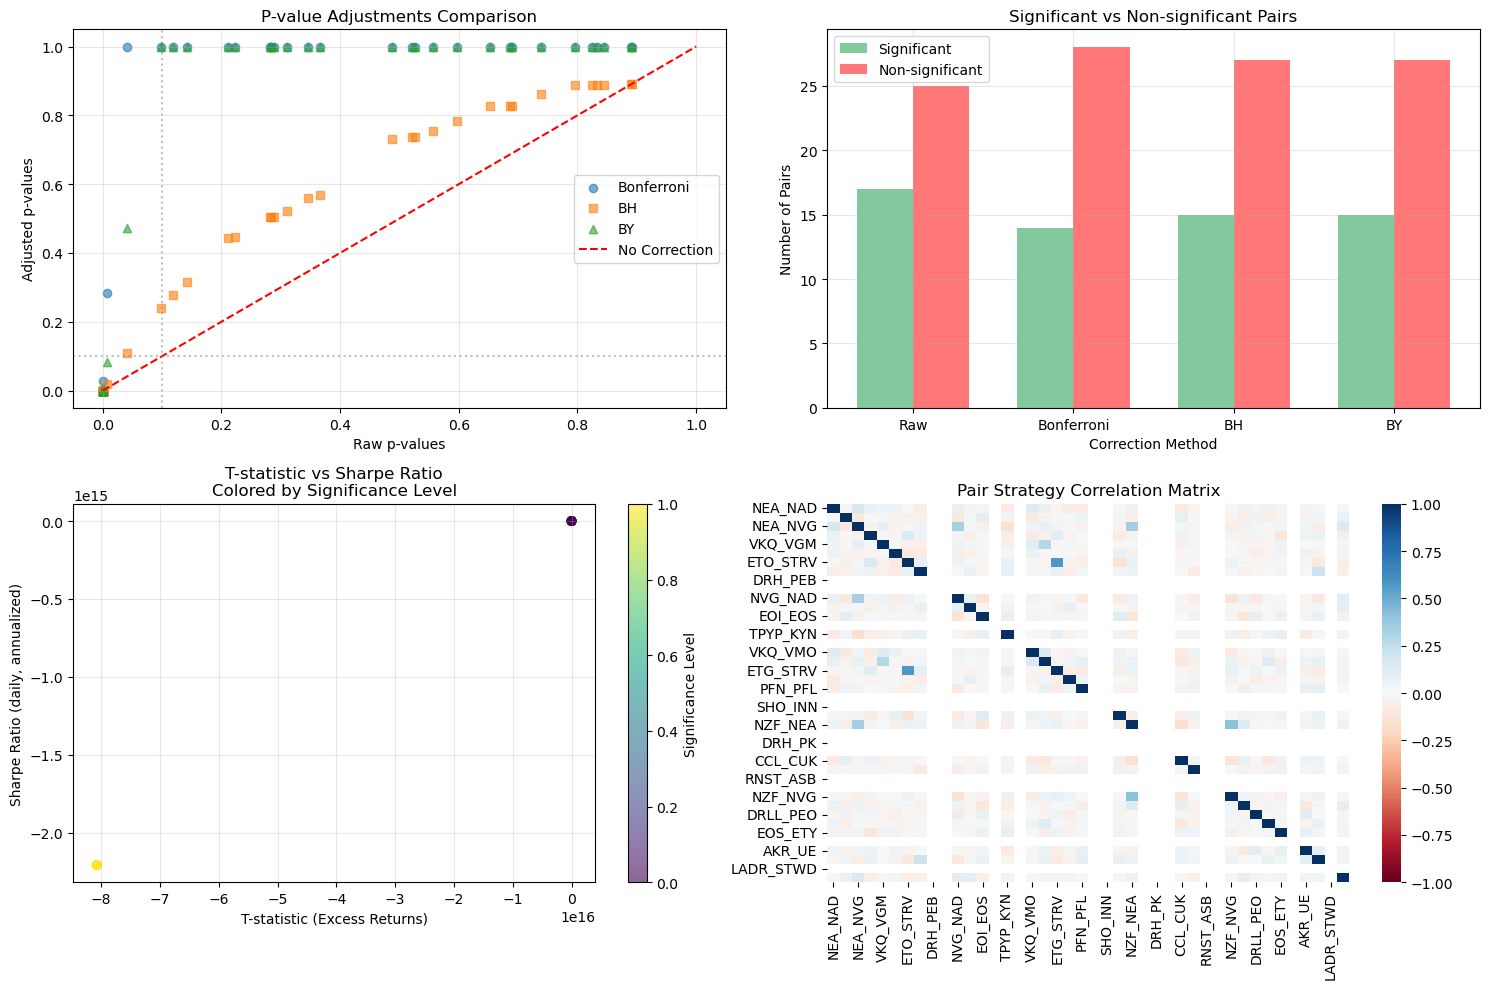

In [533]:
stats_df, corr_matrix = create_multiple_testing_visualization_pairs(
    pair_results=pair_results,
    ff5=ff5,
    notional=10_000,
    train_end="2023-12-31",
    alpha=0.10,
)
plt.show()
